### Importing all necessary library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

**Step 1 Importing the dataset of movie customer_id and Rating**

In [6]:
netflix_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/Datasets_Netflix/Copy of combined_data_1.txt.zip",
                         header = None, names = ['Cust_Id', 'Rating'], usecols = [0, 1])

In [7]:
netflix_df

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [8]:
netflix_df.isnull().sum()

,0
Cust_Id,0
Rating,4499


In [9]:
movie_count = netflix_df.isnull().sum()
movie_count = movie_count['Rating']
movie_count

4499

In [10]:
# count the total customer
customer_count = netflix_df['Cust_Id'].nunique()
customer_count

475257

In [11]:
# Actual number of customer of netflix
total_customer = customer_count - movie_count
total_customer

470758

In [12]:
# Rating count
rating_count = netflix_df['Cust_Id'].count() - movie_count
rating_count

24053764

In [13]:
# To find out how many people give different rating to the different movie
stars = netflix_df.groupby('Rating')['Cust_Id'].count()
stars

,Cust_Id
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


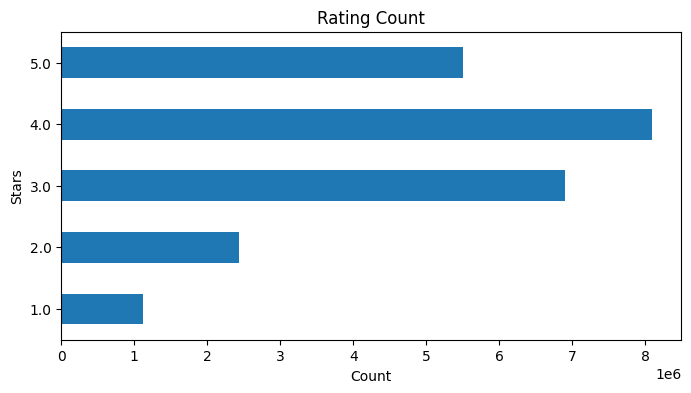

In [14]:
# Distribution of different ratings given by customer
ax = stars.plot(kind = 'barh', figsize = (8, 4))
plt.title('Rating Count')
plt.xlabel('Count')
plt.ylabel('Stars')
plt.show()

In [15]:
# to make cleardataframe for movieid
movie_id = None
movie_np = []

# Iterate over the dataFrame rows
for cust_id in netflix_df['Cust_Id']:
  if ':' in cust_id:
    movie_id = int(cust_id.replace(':', ''))
  movie_np.append(movie_id)

In [16]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [17]:
# Add the new columns movie_id
netflix_df['Movie_id'] = movie_np
netflix_df

,Cust_Id,Rating,Movie_id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [18]:
#excludes rows where the 'Rating' is NaN)to keep only the rows where the 'Rating' column is not null
netflix_df = netflix_df[netflix_df['Rating'].notna()]
netflix_df

,Cust_Id,Rating,Movie_id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [19]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [20]:
netflix_df['Cust_Id']= netflix_df['Cust_Id'].astype(int)

<ipython-input-20-ea9ac7c57ba7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_df['Cust_Id']= netflix_df['Cust_Id'].astype(int)


In [21]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [22]:
netflix_df.head()

,Cust_Id,Rating,Movie_id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [23]:
# importing the movie_title file
movie_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/Datasets_Netflix/Netflix movie_titles_SVD.csv",
                       encoding='ISO-8859-1', header=None, usecols=[0,1,2], names=['Movie_id','Year','Name' ])

In [24]:
movie_df

,Movie_id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [25]:
merged_df = pd.merge(netflix_df, movie_df, on = 'Movie_id')

In [26]:
merged_df.head()

,Cust_Id,Rating,Movie_id,Year,Name
0,1488844,3.0,1,2003.0,Dinosaur Planet
1,822109,5.0,1,2003.0,Dinosaur Planet
2,885013,4.0,1,2003.0,Dinosaur Planet
3,30878,4.0,1,2003.0,Dinosaur Planet
4,823519,3.0,1,2003.0,Dinosaur Planet


In [23]:
#merged_df.drop('Year', inplace = True, axis = 1)

In [24]:
stars = merged_df.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


In [25]:
# Droping list of movies of Rating 1 and 2
drop_movie_list = merged_df[~merged_df['Rating'].isin([1, 2])]
drop_movie_list

,Cust_Id,Rating,Movie_id,Year,Name
0,1488844,3.0,1,2003.0,Dinosaur Planet
1,822109,5.0,1,2003.0,Dinosaur Planet
2,885013,4.0,1,2003.0,Dinosaur Planet
3,30878,4.0,1,2003.0,Dinosaur Planet
4,823519,3.0,1,2003.0,Dinosaur Planet
...,...,...,...,...,...
24053756,2219917,3.0,4499,2002.0,In My Skin
24053758,2562830,4.0,4499,2002.0,In My Skin
24053761,512536,5.0,4499,2002.0,In My Skin
24053762,988963,3.0,4499,2002.0,In My Skin


In [26]:
# Prefiltering -> removing cust_id who doesnot active regularly
movie_summary = merged_df.groupby('Movie_id')['Rating'].agg(['count'])
movie_summary

,count
Movie_id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [27]:
# Remove customer who are not active  10% of the maximum active custome
cust_rating_count = merged_df.groupby('Cust_Id').size()
max_ratings = cust_rating_count.max()
# calculating the threshold value of 10 %
threshold = max_ratings * 0.1
# Get a list of active cust_id who have rated more than threshold value
active_cust_id = cust_rating_count[cust_rating_count >= threshold].index
# fliter the merged_df to include only active cust_id
merged_df = merged_df[merged_df['Cust_Id'].isin(active_cust_id)]
merged_df

,Cust_Id,Rating,Movie_id,Year,Name
0,1488844,3.0,1,2003.0,Dinosaur Planet
24,1181550,3.0,1,2003.0,Dinosaur Planet
25,1227322,4.0,1,2003.0,Dinosaur Planet
31,786312,3.0,1,2003.0,Dinosaur Planet
36,525356,2.0,1,2003.0,Dinosaur Planet
...,...,...,...,...,...
24053711,1073300,4.0,4499,2002.0,In My Skin
24053736,2385226,1.0,4499,2002.0,In My Skin
24053738,811530,4.0,4499,2002.0,In My Skin
24053745,1852040,1.0,4499,2002.0,In My Skin


**Model Building**

In [1]:
! pip install scikit-surprise

In [30]:
!pip install numpy==1.23.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 32.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.3.1 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
pymc 5.22.0 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.23.

In [2]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [3]:
reader = Reader(rating_scale = (1,5))

In [4]:
# we work only with 100 k data to quickrun
data = Dataset.load_from_df(merged_df[['Cust_Id', 'Movie_id','Rating']][:100000],reader)

NameError: name 'merged_df' is not defined

In [83]:
model = SVD()

In [84]:
cross_validate(model, data, measures = ['RMSE'], cv = 5, verbose = True)

Evaluating RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9383  0.9343  0.9397  0.9280  0.9248  0.9330  0.0058  
Fit time          1.89    1.65    1.31    1.30    1.31    1.49    0.24    
Test time         0.60    0.10    0.41    0.10    0.16    0.28    0.20    


{'test_rmse': array([0.93828981, 0.93434843, 0.93970852, 0.92802029, 0.92476199]),
 'fit_time': (1.8927717208862305,
  1.6522424221038818,
  1.3104944229125977,
  1.2976453304290771,
  1.3058571815490723),
 'test_time': (0.5966498851776123,
  0.1037142276763916,
  0.41176748275756836,
  0.10445070266723633,
  0.16277432441711426)}

In [85]:
merged_df

,Cust_Id,Rating,Movie_id,Year,Name
0,1488844,3.0,1,2003.0,Dinosaur Planet
24,1181550,3.0,1,2003.0,Dinosaur Planet
25,1227322,4.0,1,2003.0,Dinosaur Planet
31,786312,3.0,1,2003.0,Dinosaur Planet
36,525356,2.0,1,2003.0,Dinosaur Planet
...,...,...,...,...,...
24053711,1073300,4.0,4499,2002.0,In My Skin
24053736,2385226,1.0,4499,2002.0,In My Skin
24053738,811530,4.0,4499,2002.0,In My Skin
24053745,1852040,1.0,4499,2002.0,In My Skin


In [86]:
# Filter the dataset for the specific user
user_ratings = merged_df[merged_df['Cust_Id'] == 2157060]
user_ratings

,Cust_Id,Rating,Movie_id,Year,Name
23846,2157060,3.0,16,1996.0,Screamers
40196,2157060,3.0,18,1994.0,Immortal Beloved
43743,2157060,1.0,23,2001.0,Clifford: Clifford Saves the Day! / Clifford's...
44971,2157060,4.0,24,1981.0,My Bloody Valentine
85101,2157060,1.0,28,2002.0,Lilo and Stitch
...,...,...,...,...,...
23922956,2157060,2.0,4472,2003.0,Love Actually
23968952,2157060,2.0,4479,1980.0,Ordinary People
24033991,2157060,3.0,4492,2004.0,Club Dread
24040945,2157060,4.0,4493,2003.0,Ju-on: The Grudge


In [87]:
# find the unique movie rated by user
unique_movies = user_ratings['Movie_id'].nunique()
unique_movies

862

In [88]:
#making a copy for each individual customer for the recomendation
user_2157060 = movie_df.copy()
user_2157060

,Movie_id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [89]:
user_2157060=user_2157060[~user_2157060['Movie_id'].isin(drop_movie_list)]
user_2157060

,Movie_id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [90]:
user_2157060['Estimate_score'] = user_2157060['Movie_id'].apply(lambda x: model.predict(2157060, x).est)

In [91]:
user_2157060

,Movie_id,Year,Name,Estimate_score
0,1,2003.0,Dinosaur Planet,3.142811
1,2,2004.0,Isle of Man TT 2004 Review,2.207157
2,3,1997.0,Character,2.862795
3,4,1994.0,Paula Abdul's Get Up & Dance,2.339374
4,5,2004.0,The Rise and Fall of ECW,2.432104
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,2.681982
17766,17767,2004.0,Fidel Castro: American Experience,2.681982
17767,17768,2000.0,Epoch,2.681982
17768,17769,2003.0,The Company,2.681982


In [92]:
user_2157060.sort_values('Estimate_score', ascending = False)

,Movie_id,Year,Name,Estimate_score
174,175,1992.0,Reservoir Dogs,4.487024
198,199,1978.0,The Deer Hunter,4.425533
356,357,2003.0,House of Sand and Fog,3.851748
222,223,2003.0,Chappelle's Show: Season 1,3.703924
142,143,1997.0,The Game,3.543990
...,...,...,...,...
133,134,1996.0,Spirit Lost,1.574180
130,131,2002.0,Arachnid,1.568526
414,415,2002.0,Reign in Darkness,1.558865
52,53,2003.0,The Bonesetter,1.437395


In [93]:
top5_movies= user_2157060.sort_values('Estimate_score', ascending = False).head(5)
top5_movies

,Movie_id,Year,Name,Estimate_score
174,175,1992.0,Reservoir Dogs,4.487024
198,199,1978.0,The Deer Hunter,4.425533
356,357,2003.0,House of Sand and Fog,3.851748
222,223,2003.0,Chappelle's Show: Season 1,3.703924
142,143,1997.0,The Game,3.543990


In [53]:
!pip install requests tqdm

In [58]:
import pandas as pd
import requests
from tqdm import tqdm
import time

# Load your full movie list (should have 'title' and 'year')
movies = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataSets/Datasets_Netflix/Netflix movie_titles_SVD.csv',
                       encoding='ISO-8859-1', header=None, usecols=[0,1,2], names=['Movie_id','year','title' ])

# Sample 2000 random movies
sampled_movies = movies.sample(n=2000, random_state=42).copy()
sampled_movies['genre'] = None

# 🔑 Replace with your TMDB API key
API_KEY = 'Your tmdb api key'
# TMDB Search Function
def get_movie_genre(title, year):
    try:
        # Step 1: Search for the movie
        search_url = "https://api.themoviedb.org/3/search/movie"
        params = {
            'api_key': API_KEY,
            'query': title,
            'year': int(year) if pd.notna(year) else None
        }
        search_response = requests.get(search_url, params=params)
        search_data = search_response.json()

        # Step 2: If movie found, fetch its details
        if search_response.status_code == 200 and search_data['results']:
            movie_id = search_data['results'][0]['id']
            detail_url = f"https://api.themoviedb.org/3/movie/{movie_id}"
            detail_response = requests.get(detail_url, params={'api_key': API_KEY})
            if detail_response.status_code == 200:
                genres = detail_response.json().get('genres', [])
                return ', '.join([g['name'] for g in genres])
        return None
    except Exception as e:
        print(f"Error fetching genre for '{title} ({year})': {e}")
        return None

# Fetch genres for 2000 sampled movies
for i in tqdm(range(len(sampled_movies))):
    title = sampled_movies.iloc[i]['title']
    year = sampled_movies.iloc[i]['year']
    genre = get_movie_genre(title, year)
    sampled_movies.at[sampled_movies.index[i], 'genre'] = genre
    time.sleep(0.25)  # Respect API rate limits

# Save results
sampled_movies.to_csv('sampled_movies_with_genres.csv', index=False)
print("✅ Genres fetched and saved.")

100%|██████████| 2000/2000 [16:09<00:00,  2.06it/s]

✅ Genres fetched and saved.


### Find out the list of most popular and liked genre

In [94]:
import pandas as pd

# Load enriched movies data with genres
movies = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataSets/Datasets_Netflix/sampled_movies_with_genres (1).csv')  # includes movie_id and genre
movies.head()

,Movie_id,year,title,genre
0,1087,1994.0,Monkey Trouble,"Comedy, Family"
1,12404,1994.0,Uncovered,Thriller
2,10831,1972.0,The Thing With Two Heads,"Comedy, Science Fiction"
3,14781,2004.0,"Ron White: They Call Me ""Tater Salad""",Comedy
4,4937,1995.0,Chinese Odyssey 1: Pandora's Box,"Action, Adventure, Fantasy, Comedy, Romance"


In [104]:
# Merge ratings with movie genres
data = netflix_df.merge(movies[['Movie_id', 'genre']][:100000], on='Movie_id', how='inner')
data.shape

(2115386, 4)

In [105]:
# Find out the list of most popular and liked genre using SVD
import pandas as pd
from surprise import Dataset, Reader, SVD
from collections import defaultdict

# Load your datasets
#ratings = pd.read_csv('ratings.csv')               # cust_id, movie_id, rating
#movies = pd.read_csv('sampled_movies_with_genres.csv')  # movie_id, title, genre

# Clean up genres
movies = movies.dropna(subset=['genre'])
movies['genre'] = movies['genre'].str.split(', ')
movies = movies.explode('genre')

<ipython-input-105-84935f7324b5>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['genre'] = movies['genre'].str.split(', ')


In [106]:
from surprise import Dataset, Reader

# Prepare data for surprise
reader = Reader(rating_scale=(1, 5.0))
data = Dataset.load_from_df(data[['Cust_Id', 'Movie_id', 'Rating']], reader)

trainset = data.build_full_trainset()
model = SVD()
model.fit(trainset)


In [110]:
# Merge ratings with genre
merged = merged_df.merge(movies[['Movie_id', 'genre']], on='Movie_id', how='inner')

# Count number of ratings per genre
genre_popularity = merged.groupby('genre')['Rating'].count().sort_values(ascending=False).reset_index()
genre_popularity.columns = ['genre', 'num_ratings']

print("📊 Most Popular Genres (by number of ratings):")
print(genre_popularity.head())


📊 Most Popular Genres (by number of ratings):
       genre  num_ratings
0      Drama        41283
1     Comedy        40277
2   Thriller        24115
3     Action        21735
4  Adventure        18746


In [112]:
# Create list of all unique user and movie pairs
all_users = merged_df['Cust_Id'].unique()
all_movies = movies[['Movie_id', 'genre']].drop_duplicates()

predictions = []

for genre in all_movies['genre'].unique():
    genre_movies = all_movies[all_movies['genre'] == genre]
    for _, movie_row in genre_movies.iterrows():
        movie_id = movie_row['Movie_id']
        for user_id in all_users:
            pred = model.predict(user_id, movie_id).est
            predictions.append((genre, movie_id, user_id, pred))

# Create predictions DataFrame
pred_df = pd.DataFrame(predictions, columns=['genre', 'Movie_id', 'Cust_Id', 'predicted_rating'])


In [113]:
# Average predicted rating per genre
genre_likes = pred_df.groupby('genre')['predicted_rating'].mean().sort_values(ascending=False).reset_index()
genre_likes.columns = ['genre', 'avg_predicted_rating']

print("❤️ Most Liked Genres (by predicted rating):")
print(genre_likes.head())

❤️ Most Liked Genres (by predicted rating):
         genre  avg_predicted_rating
0    Animation              3.267072
1      History              3.248028
2        Music              3.232397
3       Family              3.228333
4  Documentary              3.213126


In [115]:
user_id = 2157060  # 🔁 Replace with target user

# Get movies the user hasn't rated
rated_movies = netflix_df[netflix_df['Cust_Id'] == user_id]['Movie_id'][:100000].unique()
unseen_movies = movies[~movies['Movie_id'].isin(rated_movies)]

# Predict ratings
unseen_movies = unseen_movies.drop_duplicates(subset=['Movie_id', 'genre'])

# Predict and store results
predictions = []
for row in unseen_movies.itertuples():
    pred = model.predict(user_id, row.Movie_id)
    predictions.append((row.genre, row.Movie_id, row.title, pred.est))

# Convert to DataFrame
pred_df = pd.DataFrame(predictions, columns=['genre', 'Movie_id', 'title', 'predicted_rating'])


In [116]:
# Sort and get top 1 per genre
top_movies = pred_df.sort_values(['genre', 'predicted_rating'], ascending=[True, False])
recommendations = top_movies.groupby('genre').head(1).reset_index(drop=True)

print("🎬 Top Recommended Movie per Genre for User", user_id)
print(recommendations[['genre', 'title', 'predicted_rating']])

🎬 Top Recommended Movie per Genre for User 2157060
              genre                                              title  \
0            Action                            Mobile Suit Gundam SEED   
1         Adventure                          Aguirre: The Wrath of God   
2         Animation                            Mobile Suit Gundam SEED   
3            Comedy                                       Modern Times   
4             Crime                             Shadow of the Thin Man   
5       Documentary      Unprecedented: The 2000 Presidential Election   
6             Drama                            Mobile Suit Gundam SEED   
7            Family                                 My Neighbor Totoro   
8           Fantasy                                 My Neighbor Totoro   
9           History                          Aguirre: The Wrath of God   
10           Horror                      The Return of the Living Dead   
11            Music  Bjork: The Inner or Deep Part of an Anim